# 📘 Classification Binaire : Photo vs Non-Photo
Ce notebook implémente un modèle CNN basé sur **EfficientNetB0** pour distinguer les **photos réelles** des **images non-photo** (graphiques, peintures, schémas, etc.).

## 1️⃣ Importation des librairies

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

# Reproducibility & performance
tf.keras.utils.set_random_seed(42)
AUTOTUNE = tf.data.AUTOTUNE


2025-10-08 17:19:15.176755: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2️⃣ Chargement et Prétraitement des Données

In [3]:
IMG_SIZE = 128
BATCH_SIZE = 32
DATA_ROOT = Path("data/raw").resolve()

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Le dossier de données attendu {DATA_ROOT} est introuvable."
    )

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print(f"Classes détectées: {class_names}")


def configure_dataset(dataset, training=False):
    dataset = dataset.cache()
    if training:
        dataset = dataset.shuffle(buffer_size=256, seed=42)
    return dataset.prefetch(buffer_size=AUTOTUNE)


train_ds = configure_dataset(train_ds, training=True)
val_ds = configure_dataset(val_ds)


Found 41398 files belonging to 2 classes.
Using 33119 files for training.


I0000 00:00:1759944017.223620      27 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1765 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Found 41398 files belonging to 2 classes.
Using 8279 files for validation.
Classes détectées: ['non_photo', 'photo']


## 3️⃣ Construction du Modèle CNN avec Régularisation

In [4]:
data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

pixel_normalization = layers.Rescaling(1.0 / 255.0, name="pixel_normalization")

reg = regularizers.l2(1e-4)

def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(filters, 3, padding="same", use_bias=False, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    return layers.MaxPooling2D()(x)

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = pixel_normalization(x)
x = conv_block(x, 32)
x = layers.Dropout(0.2)(x)
x = conv_block(x, 64)
x = layers.Dropout(0.3)(x)
x = conv_block(x, 128)
x = layers.Dropout(0.4)(x)
x = layers.Conv2D(256, 3, padding="same", activation="relu", kernel_regularizer=reg)(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs, name="photo_classifier_cnn")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()


Model: "photo_classifier_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pixel_normalization (Rescaling) │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 616,545 (2.35 MB)

 Trainable params: 615,649 (2.35 MB)

 Non-trainable params: 896 (3.50 KB)

## 4️⃣ Entraînement avec Early Stopping et Learning Rate Scheduler

In [5]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    verbose=1,
)

history = model.fit(
    train_ds,
    epochs=25,
    validation_data=val_ds,
    callbacks=[early_stop, lr_scheduler],
)


Epoch 1/25


E0000 00:00:1759944074.989994      27 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/photo_classifier_cnn_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-10-08 17:21:25.274306: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:15: Filling up shuffle buffer (this may take a while): 170 of 256
2025-10-08 17:21:28.432620: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2025-10-08 17:21:29.843963: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800
2025-10-08 17:21:33.554809: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.21GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7937 - loss: 0.4400

2025-10-08 17:23:52.182623: W tensorflow/core/lib/png/png_io.cc:95] PNG warning: iCCP: known incorrect sRGB profile
Corrupt JPEG data: 419 extraneous bytes before marker 0xd9


1035/1035 ━━━━━━━━━━━━━━━━━━━━ 167s 141ms/step - accuracy: 0.8221 - loss: 0.4049 - val_accuracy: 0.8485 - val_loss: 0.4158 - learning_rate: 1.0000e-04
Epoch 2/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 127s 122ms/step - accuracy: 0.8617 - loss: 0.3538 - val_accuracy: 0.8814 - val_loss: 0.3219 - learning_rate: 1.0000e-04
Epoch 3/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 130s 125ms/step - accuracy: 0.8763 - loss: 0.3281 - val_accuracy: 0.8846 - val_loss: 0.3243 - learning_rate: 1.0000e-04
Epoch 4/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 129s 124ms/step - accuracy: 0.8866 - loss: 0.3094 - val_accuracy: 0.8831 - val_loss: 0.3217 - learning_rate: 1.0000e-04
Epoch 5/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 128s 124ms/step - accuracy: 0.8947 - loss: 0.2936 - val_accuracy: 0.8750 - val_loss: 0.3355 - learning_rate: 1.0000e-04
Epoch 6/25
1035/1035 ━━━━━━━━━━━━━━━━━━━━ 535s 517ms/step - accuracy: 0.8989 - loss: 0.2811 - val_accuracy: 0.9071 - val_loss: 0.2727 - learning_rate: 1.0000e-04
Epoch 7/25
1035/1035 ━━━━━━━━━━━━━━━━━━

## 5️⃣ Visualisation des Courbes d’Entraînement

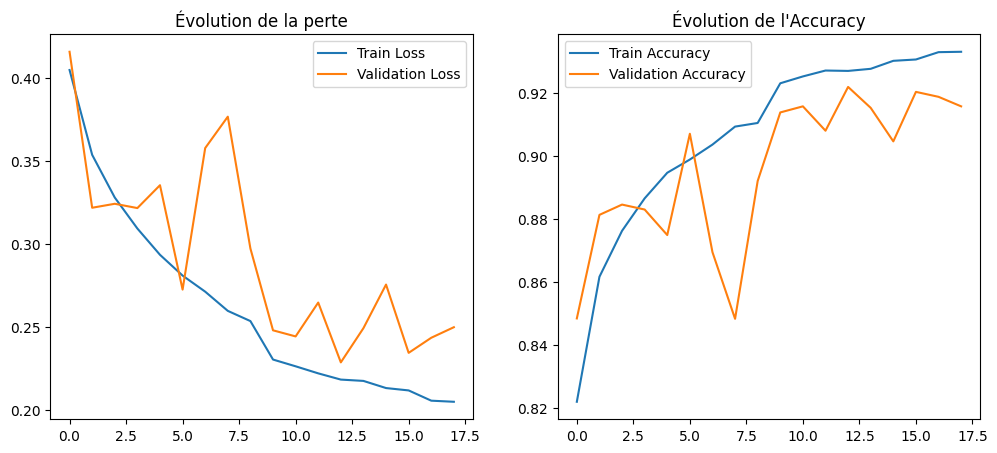

In [6]:

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de la perte')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Évolution de l'Accuracy")
plt.legend()
plt.show()


## 6️⃣ Évaluation sur le jeu de validation

2025-10-08 18:15:29.619839: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


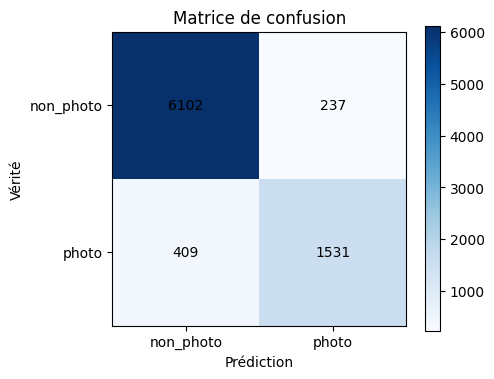

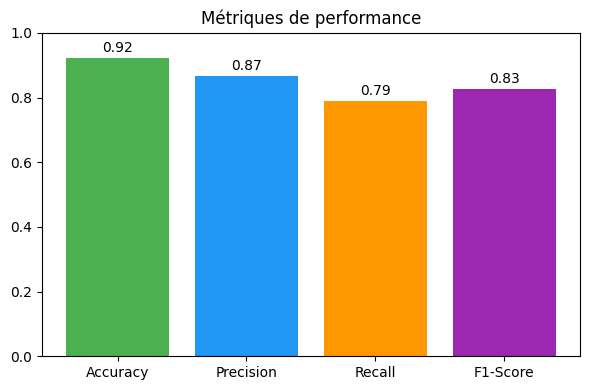

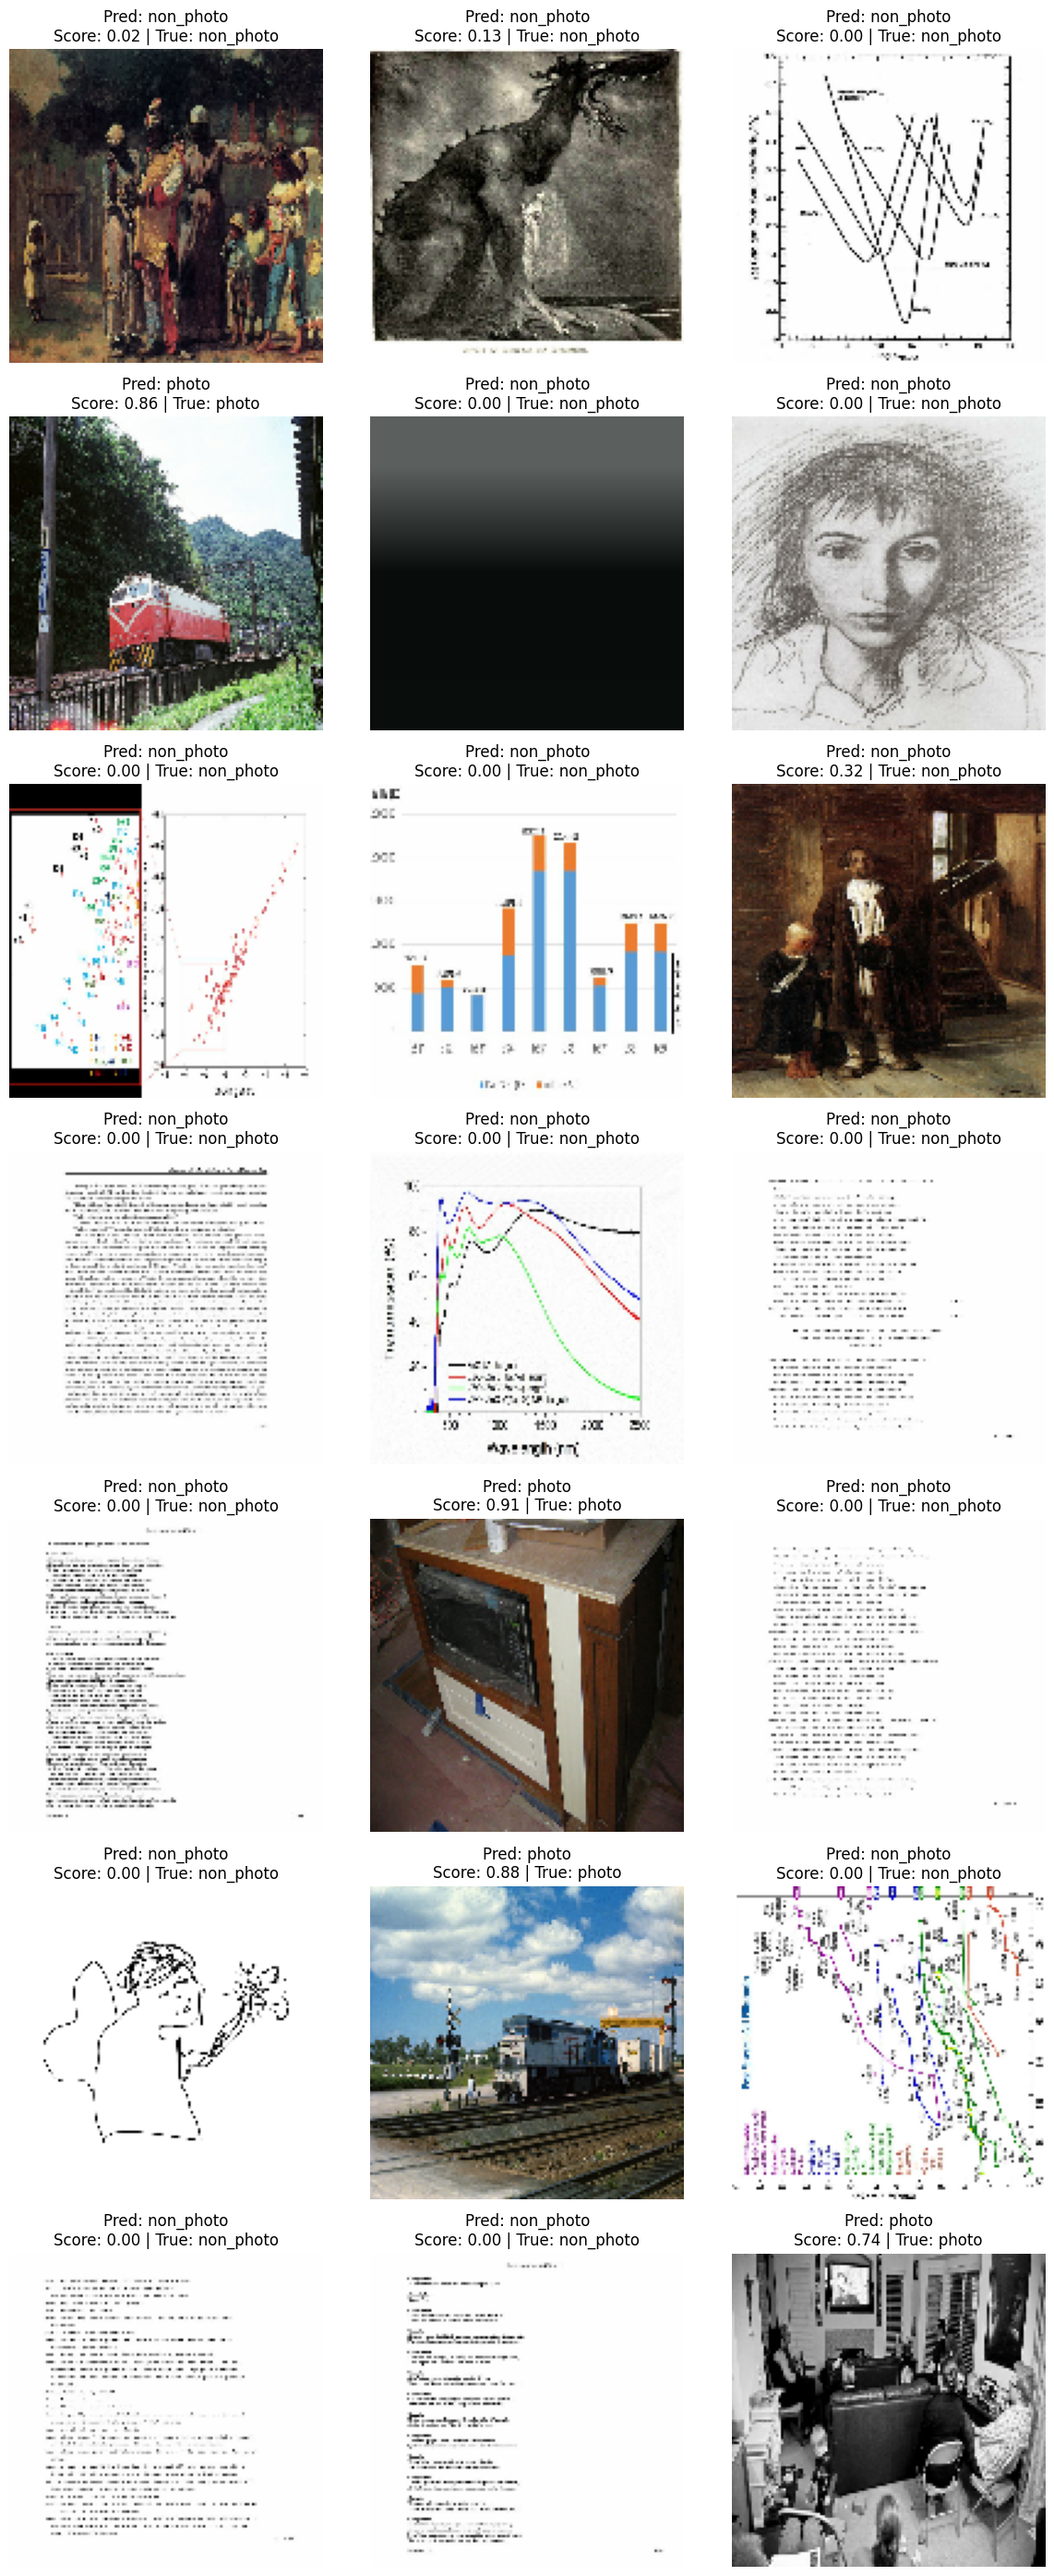

In [8]:
val_true = []
val_scores = []
sample_images = []
sample_labels = []
sample_scores = []

for batch_images, batch_labels in val_ds:
    batch_preds = model.predict(batch_images, verbose=0).squeeze()
    val_scores.extend(np.atleast_1d(batch_preds).tolist())
    val_true.extend(batch_labels.numpy().tolist())
    if len(sample_images) < 6:
        remaining = 6 - len(sample_images)
        take = min(remaining, batch_images.shape[0])
        if take > 0:
            sample_images.append(batch_images[:take].numpy())
            sample_labels.append(batch_labels[:take].numpy())
            sample_scores.append(np.atleast_1d(batch_preds)[:take])

has_samples = len(sample_images) > 0
if has_samples:
    sample_images = np.concatenate(sample_images, axis=0)
    sample_labels = np.concatenate(sample_labels, axis=0)
    sample_scores = np.concatenate(sample_scores, axis=0)

val_true = np.array(val_true)
val_scores = np.array(val_scores)
val_pred_labels = (val_scores >= 0.5).astype(int)

conf_matrix = tf.math.confusion_matrix(val_true, val_pred_labels, num_classes=2).numpy()
tn, fp, fn, tp = conf_matrix.ravel().astype(np.float32)

metrics = {
    "Accuracy": (tp + tn) / max(tn + fp + fn + tp, 1.0),
    "Precision": tp / max(tp + fp, 1.0),
    "Recall": tp / max(tp + fn, 1.0),
}
metrics["F1-Score"] = 2 * metrics["Precision"] * metrics["Recall"] / max(metrics["Precision"] + metrics["Recall"], 1e-8)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(conf_matrix, cmap="Blues")
ax.set_title("Matrice de confusion")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Vérité")
ax.set_xticks([0, 1], labels=class_names)
ax.set_yticks([0, 1], labels=class_names)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        ax.text(j, i, int(conf_matrix[i, j]), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color=["#4caf50", "#2196f3", "#ff9800", "#9c27b0"])
plt.ylim(0, 1)
plt.title("Métriques de performance")
for idx, value in enumerate(metrics.values()):
    plt.text(idx, value + 0.02, f"{value:.2f}", ha="center")
plt.tight_layout()
plt.show()

if has_samples:
    cols = 3
    rows = int(np.ceil(sample_images.shape[0] / cols))
    plt.figure(figsize=(12, 4 * rows))
    for idx in range(sample_images.shape[0]):
        ax = plt.subplot(rows, cols, idx + 1)
        ax.imshow(np.clip(sample_images[idx], 0, 255).astype("uint8"))
        pred_label = class_names[int(sample_scores[idx] >= 0.5)]
        true_label = class_names[int(sample_labels[idx])]
        ax.set_title(f"Pred: {pred_label}\nScore: {sample_scores[idx]:.2f} | True: {true_label}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

## 7️⃣ Tests manuels sur des images individuelles

⚠️ Les chemins par défaut ne sont pas valides. Sélection automatique d'exemples.
[{'chemin': 'non_photo/000_1_1_sz1.jpg',
  'classe_attendue': 'non_photo',
  'classe_predite': 'non_photo',
  'image': '000_1_1_sz1.jpg',
  'score_photo': 0.0013121470110490918},
 {'chemin': 'photo/photo_0001.jpg',
  'classe_attendue': 'photo',
  'classe_predite': 'photo',
  'image': 'photo_0001.jpg',
  'score_photo': 0.8562642931938171}]


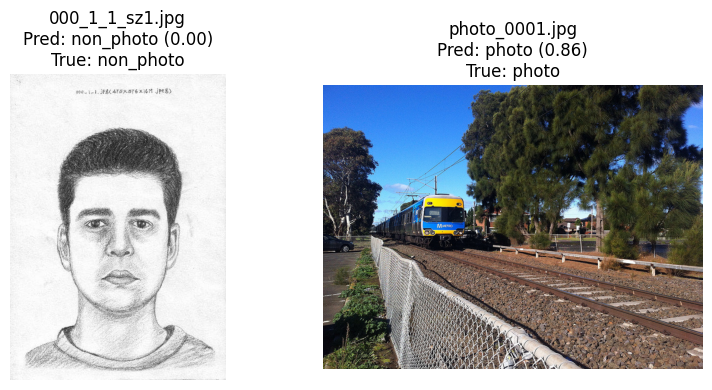

In [16]:
from tensorflow.keras.utils import load_img, img_to_array
from pprint import pprint
%matplotlib inline

# ❗️ Modifiez cette liste pour tester d'autres images manuellement
test_image_paths = [
    DATA_ROOT / class_names[0] / "photo_9999.jpg",
    DATA_ROOT / class_names[-1] / "Wp-059-1-sz1.jpg",
]

auto_paths = []
for class_name in class_names:
    class_dir = (DATA_ROOT / class_name)
    if class_dir.is_dir():
        for candidate in sorted(class_dir.glob("*")):
            if candidate.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                auto_paths.append(candidate)
                break

if not any(path.exists() for path in test_image_paths):
    print("⚠️ Les chemins par défaut ne sont pas valides. Sélection automatique d'exemples.")
    test_image_paths = auto_paths[:6]

results = []
figures = []

for path in test_image_paths:
    if not path.exists():
        print(f"[SKIP] Fichier introuvable: {path}")
        continue

    original_img = load_img(path)
    resized_img = load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(resized_img)
    score = float(model.predict(img_array[None, ...], verbose=0)[0][0])
    pred_label = class_names[int(score >= 0.5)]
    true_label = path.parent.name
    results.append({
        "image": path.name,
        "chemin": str(path.relative_to(DATA_ROOT)),
        "classe_attendue": true_label,
        "score_photo": score,
        "classe_predite": pred_label,
    })
    figures.append((path.name, np.array(original_img), score, pred_label, true_label))

if not results:
    raise RuntimeError("Aucune image valide n'a été trouvée. Mettez à jour test_image_paths avec des chemins existants.")

pprint(results)

cols = 3
rows = int(np.ceil(len(figures) / cols)) or 1
plt.figure(figsize=(12, 4 * rows))
for idx, (name, image, score, pred, true) in enumerate(figures, start=1):
    ax = plt.subplot(rows, cols, idx)
    ax.imshow(image)
    ax.set_title(f"{name}\nPred: {pred} ({score:.2f})\nTrue: {true}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8️⃣ Analyse Biais / Variance
- Si la **val_loss** reste beaucoup plus élevée que la **train_loss** → overfitting (variance trop élevée).
  → Solutions : plus de données, augmenter dropout, data augmentation, régularisation L2, early stopping.

- Si la **train_loss** est trop élevée et la **val_loss** aussi → underfitting (biais trop fort).
  → Solutions : modèle plus complexe, dégel partiel du `base_model`, learning rate plus élevé.

## 9️⃣ Améliorations Possibles
- **Fine-tuning** : dégel des dernières couches du modèle de base après quelques epochs.
- **Dropout dynamique** : augmenter progressivement pendant l’entraînement.
- **Data augmentation avancée** : ajout de transformations de couleur, bruit, flou, etc.
- **Batch Normalization** : stabilise et accélère l’apprentissage.